<a href="https://colab.research.google.com/github/HanaaMaswada/Prediction-of-Product-Sales/blob/main/project_4_adult_income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Imports and Options

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score
)

# Permutation Importance
from sklearn.inspection import permutation_importance

# Display Options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

2. Load Data

In [ ]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/axsos ass/adult.csv')

# Preview
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


3. Explore the Dataset

In [ ]:
df.shape

(48842, 15)

In [ ]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
df.duplicated().sum()

np.int64(52)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['income'].value_counts()

,count
income,
<=50K,37109
>50K,11681


4. Define Target and Features

In [ ]:
target = 'income'

In [ ]:
X = df.drop(columns=target)
y = df[target]

5. Exploratory Visualizations

Income distribution

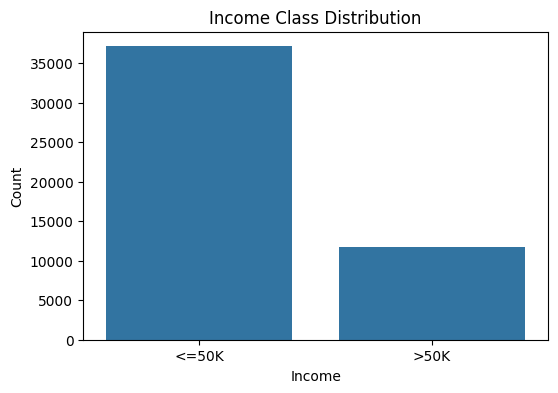

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='income')

plt.title('Income Class Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

Age distribution by income

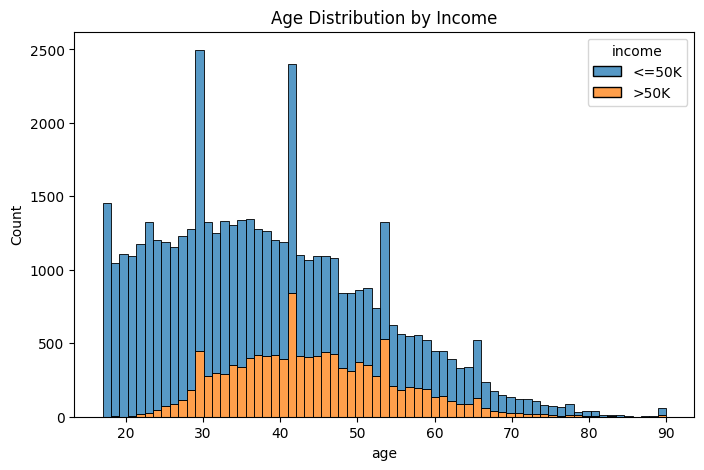

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    hue='income',
    multiple='stack'
)

plt.title('Age Distribution by Income')
plt.show()

Education vs Income

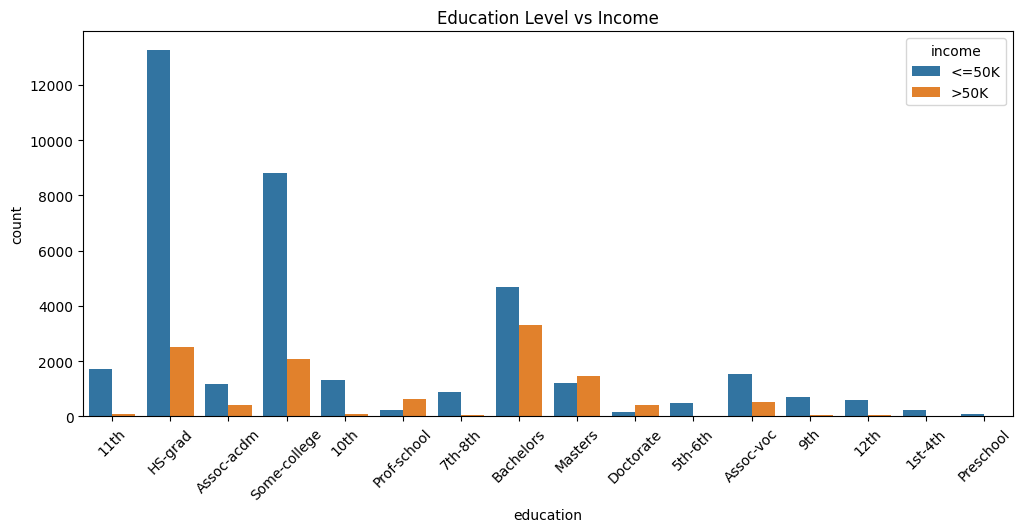

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='education',
    hue='income'
)

plt.xticks(rotation=45)

plt.title('Education Level vs Income')

plt.show()

Hours per week vs Income

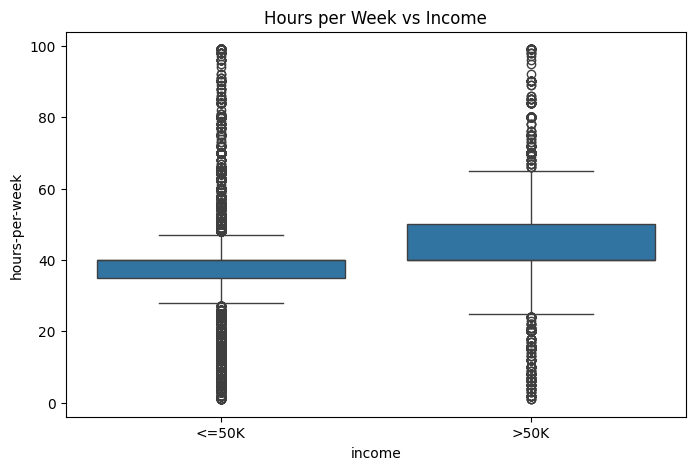

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Hours per Week vs Income')

plt.show()

6. Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)

7. Identify Numeric and Categorical Columns

In [ ]:
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(exclude='number').columns

print(num_cols)
print(cat_cols)

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object')


8. Preprocessing

Numeric preprocessing

In [ ]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Categorical preprocessing

In [ ]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Combine preprocessing

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

9. Create Default Model

In [ ]:
rf_clf = RandomForestClassifier(random_state=42)

10. Create Full Pipeline

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_clf)
])

11. Fit the Model

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

12. Predictions

In [ ]:
y_pred = model.predict(X_test)

13. Evaluate the Model

Accuracy

In [ ]:
accuracy_score(y_test, y_pred)

0.8534535765525723

Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91      7422
        >50K       0.72      0.63      0.67      2336

    accuracy                           0.85      9758
   macro avg       0.80      0.78      0.79      9758
weighted avg       0.85      0.85      0.85      9758



Confusion Matrix

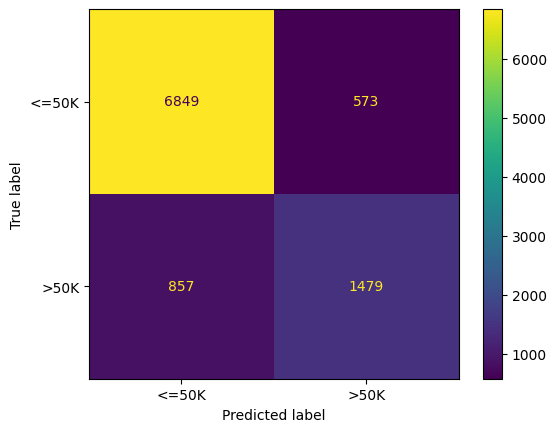

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

14. Permutation Importance


Run permutation importance

In [ ]:
results = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42
)

15. Create Importance DataFrame

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': results.importances_mean
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
10,capital-gain,0.039045
5,marital-status,0.021664
6,occupation,0.012708
0,age,0.012462
11,capital-loss,0.007563
7,relationship,0.007563
12,hours-per-week,0.006333
4,educational-num,0.005780
2,fnlwgt,0.002480
1,workclass,0.002378


16. Visualize Top 10 Features

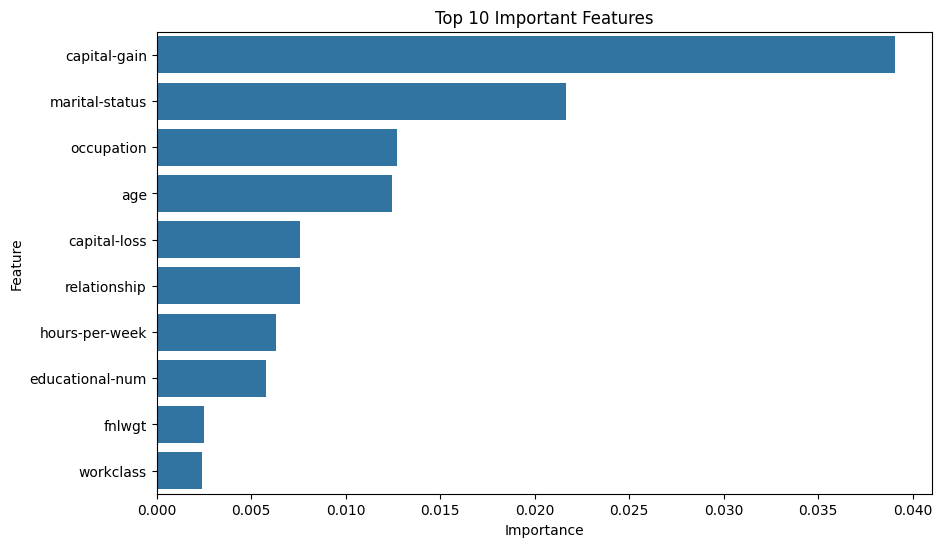

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')

plt.show()

17. Explanatory Visualization

Age vs Income

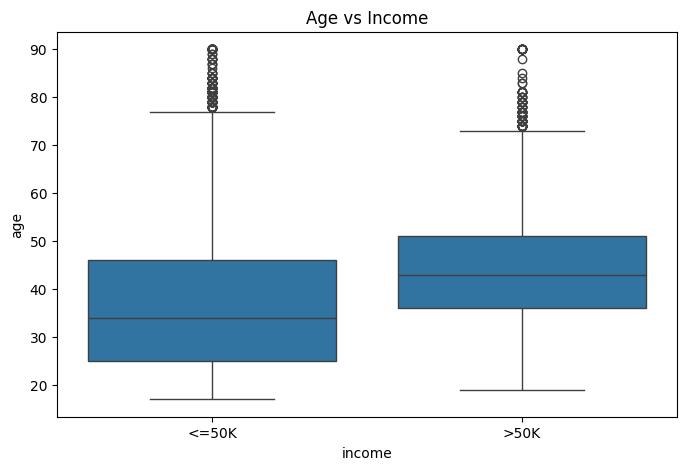

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='age'
)

plt.title('Age vs Income')

plt.show()

18. Explanatory Visualization #2

Hours Worked vs Income

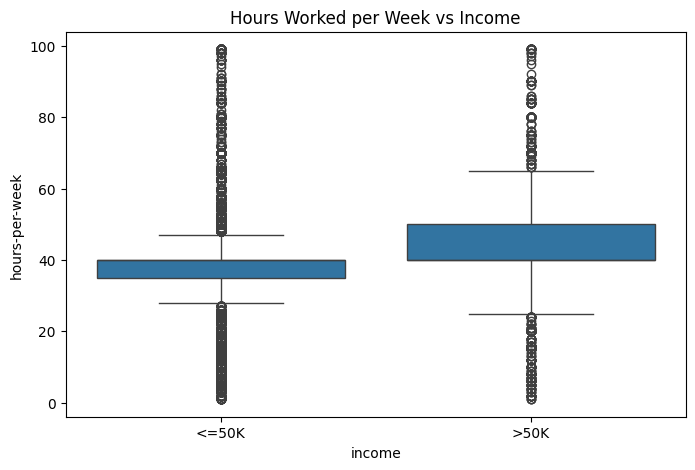

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Hours Worked per Week vs Income')

plt.show()

# Final Observations

- The Random Forest model achieved strong classification performance with an accuracy of approximately 85%.

- Permutation importance revealed that capital-gain, marital-status, occupation, age, and hours-per-week were among the most influential features in predicting income level.

- Individuals with higher education levels and longer working hours were more likely to earn more than 50K annually.

- The visualizations showed clear relationships between demographic and work-related features and income category.

- Preprocessing steps such as handling categorical variables, scaling numerical data, and using pipelines improved the modeling workflow and organization.

- Overall, the project demonstrated how machine learning can be used to identify important socioeconomic factors associated with income prediction.